<a href="https://colab.research.google.com/github/alinebbrasil/pg_ciencia_de_dados/blob/main/MVP_Analise_de_Dados_e_Boas_Praticas/MVP_Analise_de_Dados_e_Boas_Praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Aline Bastos Brasil

**Matrícula:** 2026001

**Dataset:** [Amazon Sales Dataset](https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset)


# Descrição do Problema

Este projeto tem como objetivo realizar uma análise exploratória de dados de produtos da Amazon, buscando compreender padrões relacionados a preços, avaliações e categorias.

A análise visa identificar possíveis relações entre o valor dos produtos e suas avaliações, bem como explorar a distribuição dos produtos entre diferentes categorias.

Além disso, busca-se identificar possíveis padrões que possam indicar tendências de mercado ou comportamento dos consumidores.

## Hipóteses do Problema


Para orientar a análise exploratória, foram definidas as seguintes hipóteses:


1. **Produtos com menor preço tendem a possuir avaliações mais altas.**
2. **Produtos com maior número de avaliações tendem a apresentar ratings mais elevados.**
3. **Existem diferenças significativas de preço entre as categorias de produtos.**
4. **Produtos com maiores descontos tendem a possuir melhores avaliações.**
5. **Algumas categorias concentram a maior parte dos produtos disponíveis.**

## Tipo de Problema

Este projeto não se caracteriza como um problema de aprendizado supervisionado ou não supervisionado, pois não há uma variável alvo a ser prevista.

Trata-se de uma análise exploratória de dados (EDA), cujo objetivo é compreender a estrutura dos dados, identificar padrões e extrair insights relevantes.

## Seleção de Dados

O dataset utilizado neste projeto foi selecionado a partir da plataforma Kaggle, por se tratar de uma base pública, estruturada e adequada para análise exploratória de dados.

A escolha foi motivada pela disponibilidade de informações relevantes sobre produtos, como preços, avaliações e categorias, permitindo a investigação de padrões e relações entre essas variáveis.

Além disso, optou-se por um dataset com estrutura clara e sem inconsistências aparentes, facilitando o desenvolvimento das etapas de análise e pré-processamento.

A seleção também considerou a facilidade de interpretação dos dados e o potencial para geração de insights relevantes.

# Importação das Bibliotecas Necessárias e Carga de Dados

Nesta etapa, são importadas as bibliotecas necessárias para a análise dos dados, bem como o dataset a ser utilizado no projeto.

In [28]:
# bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# carregamento do dataset e transformação em dataframe
url = 'https://raw.githubusercontent.com/alinebbrasil/pg_ciencia_de_dados/refs/heads/main/MVP_Analise_de_Dados_e_Boas_Praticas/amazon.csv'
df = pd.read_csv(url)

In [30]:
# melhoria de leitura dos números
# primeiras linhas
pd.options.display.float_format = '{:,.2f}'.format
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


Apenas a nível de curiosidade, o símbolo ₹ representa a Rúpia Indiana (INR), a moeda oficial da Índia.

## Atributos do Dataset


In [31]:
# definição de atributos
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

O dataset utilizado é composto pelos seguintes atributos:

* **product_id**: identificador único do produto.
* **product_name**: nome do produto disponível na plataforma.
* **category**: categoria à qual o produto pertence.
* **discounted_price**: preço do produto com desconto aplicado.
* **actual_price**: preço original do produto sem desconto.
* **discount_percentage**: percentual de desconto oferecido no produto.
* **rating**: avaliação média do produto atribuída pelos usuários.
* **rating_count**: quantidade de avaliações recebidas pelo produto.
* **about_product**: descrição geral do produto.
* **user_id**: identificador do usuário que realizou a avaliação.
* **user_name**: nome do usuário que realizou a avaliação.
* **review_id**: identificador único da avaliação.
* **review_title**: título da avaliação feita pelo usuário.
* **review_content**: conteúdo textual da avaliação.
* **img_link**: link da imagem do produto.
* **product_link**: link da página do produto na plataforma.


O dataset apresenta uma combinação de variáveis numéricas e categóricas, além de dados textuais, permitindo análises relacionadas a preços, avaliações e características dos produtos.

# Análise de Dados

A análise exploratória de dados será conduzida com o objetivo de compreender a estrutura do dataset e extrair insights relevantes sobre os produtos da Amazon.

Inicialmente, será realizada uma análise descritiva dos dados, incluindo a verificação de tipos de variáveis, identificação de valores ausentes e cálculo de estatísticas descritivas.

Posteriormente, serão utilizadas visualizações gráficas para explorar a distribuição dos atributos e investigar possíveis relações entre variáveis, como preço, avaliações e categorias.

Ao final, espera-se identificar padrões e tendências que auxiliem na interpretação dos dados e na geração de insights sobre o comportamento dos produtos e dos usuários.

## Total e Tipo das Instâncias


In [32]:
# tipos de dados
df.info()
# quantidade de linhas e colunas
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

(1465, 16)

O dataset possui 1465 instâncias (linhas) e 16 atributos (colunas).

Em relação aos tipos de dados, observa-se que todas as variáveis estão classificadas como do tipo object, indicando que os dados são armazenados como texto.

Além disso, foi identificada a presença de valores ausentes na coluna rating_count, que possui 1463 valores não nulos, indicando a existência de 2 registros faltantes.

A predominância de dados do tipo textual sugere a necessidade de etapas de pré-processamento, especialmente para conversão de variáveis numéricas que estão armazenadas como texto, como preços, avaliações e porcentagens de desconto.

## Estatísticas Descritivas


In [33]:
# limpeza dos dados (conversões para padronizar as strings, transformações de erros)
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['actual_price'] = (
    df['actual_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['discount_percentage'] = (
    df['discount_percentage']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
)

df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

df['rating'] = (
    df['rating']
    .astype(str)
    .str.strip()
)

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['rating_count'] = (
    df['rating_count']
    .astype(str)
    .str.replace(',', '', regex=False)
)

In [34]:
# conversão dos dados para numéricos
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

In [35]:
# conferência
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

Após a conversão dos dados, observa-se que os atributos numéricos foram corretamente tipados, sendo representados por float64 e int64.

A coluna discount_percentage foi identificada como int64, indicando que os valores de desconto são inteiros, enquanto os demais atributos numéricos, como preços e avaliações, permanecem como float64.

As colunas relacionadas a preços, porcentagem de desconto, avaliações e quantidade de avaliações foram convertidas de texto para valores numéricos.

Além disso, foram identificados valores ausentes nas colunas rating (1 valor faltante) e rating_count (2 valores faltantes), resultantes do processo de conversão e da presença de dados inconsistentes no dataset original.

A maior parte dos atributos permanece como object, representando dados categóricos e textuais, como nomes de produtos, categorias e conteúdos de avaliações.

In [36]:
# estatísticas descritivas básicas do dataset
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,"1,465.00","1,465.00","1,465.00","1,464.00","1,463.00"
mean,"3,125.31","5,444.99",47.69,4.10,"18,295.54"
std,"6,944.30","10,874.83",21.64,0.29,"42,753.86"
min,39.00,39.00,0.00,2.00,2.00
25%,325.00,800.00,32.00,4.00,"1,186.00"
50%,799.00,"1,650.00",50.00,4.10,"5,179.00"
75%,"1,999.00","4,295.00",63.00,4.30,"17,336.50"
max,"77,990.00","139,900.00",94.00,5.00,"426,973.00"


A análise das estatísticas descritivas dos atributos numéricos revela informações importantes sobre o comportamento dos dados.

Observa-se que os preços dos produtos apresentam alta variabilidade, com média de aproximadamente 3.125 para o preço com desconto e 5.444 para o preço original. Os valores máximos atingem 77.990 e 139.900, respectivamente, indicando a presença de produtos com preços significativamente elevados em relação à média.

Os quartis mostram que a maior parte dos produtos está concentrada em faixas de preço mais baixas, com 50% dos produtos apresentando preços com desconto inferiores a 799, o que sugere uma distribuição assimétrica com presença de outliers.

Em relação ao percentual de desconto, a média é de aproximadamente 47,69%, indicando que muitos produtos são vendidos com descontos relevantes, sendo comum valores próximos a 50%.

As avaliações dos produtos (rating) apresentam baixa variabilidade, com média de 4,1 e desvio padrão reduzido, indicando que a maioria dos produtos possui avaliações altas e relativamente homogêneas.

Já a quantidade de avaliações (rating_count) apresenta grande dispersão, com média de aproximadamente 18.295, mas com valores máximos que ultrapassam 400 mil, evidenciando que alguns produtos são extremamente populares, enquanto outros possuem baixa visibilidade.

### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [37]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
discounted_price,"3,125.31"
actual_price,"5,444.99"
discount_percentage,47.69
rating,4.10
rating_count,"18,295.54"


### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [38]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
discounted_price,"6,944.30"
actual_price,"10,874.83"
discount_percentage,21.64
rating,0.29
rating_count,"42,753.86"


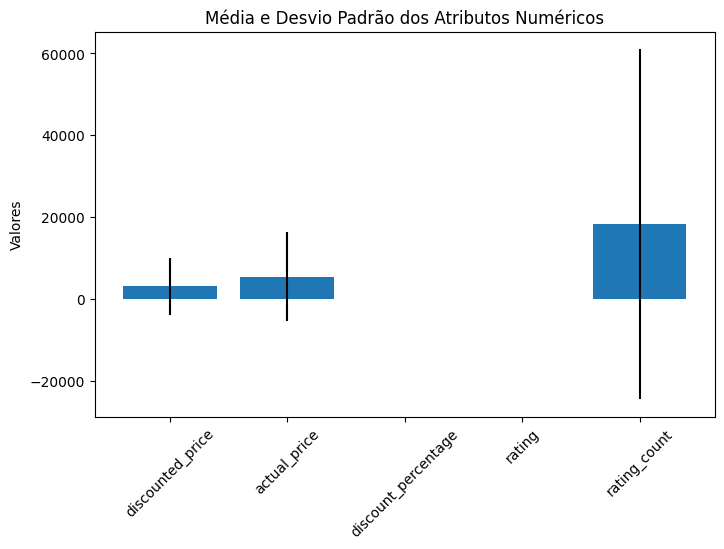

In [39]:
# selecionando colunas numéricas
cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

mean_values = df[cols].mean()
std_values = df[cols].std()

plt.figure(figsize=(8,5))
plt.bar(cols, mean_values, yerr=std_values)
plt.title('Média e Desvio Padrão dos Atributos Numéricos')
plt.xticks(rotation=45)
plt.ylabel('Valores')
plt.show()

Para melhor visualização das estatísticas descritivas, foi construído um gráfico de barras representando a média dos atributos numéricos, acompanhado do desvio padrão.

Observa-se que atributos como preço e quantidade de avaliações apresentam maior variabilidade, refletida pelos elevados desvios padrão.

No entanto, ao representar graficamente a média e o desvio padrão dos atributos numéricos em um único gráfico, observa-se que algumas variáveis, como rating e discount_percentage, não aparecem de forma visível.

Isso ocorre devido à grande diferença de escala entre os atributos analisados. Enquanto variáveis como discounted_price, actual_price e principalmente rating_count apresentam valores em ordens de grandeza muito superiores, atributos como rating (com valores próximos de 4) e discount_percentage (em torno de dezenas) tornam-se visualmente insignificantes no mesmo eixo.

Dessa forma, a ausência visual desses atributos no gráfico não indica falta de dados ou erro na análise, mas sim uma limitação da representação gráfica quando variáveis com escalas muito distintas são exibidas simultaneamente.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

**Para a análise por meio de histogramas, foram selecionadas as variáveis discounted_price, actual_price e rating, por serem as mais relevantes para a compreensão do comportamento dos dados.**

**As variáveis de preço (discounted_price e actual_price) foram escolhidas por permitirem analisar a distribuição dos valores dos produtos, identificar assimetrias e detectar a presença de outliers, além de possibilitar a comparação entre preços originais e com desconto.**

**Já a variável rating foi selecionada por representar a percepção dos usuários em relação aos produtos, trazendo uma perspectiva diferente da análise de preços e permitindo avaliar o comportamento das avaliações.**

**Dessa forma, a escolha dessas variáveis buscou equilibrar a análise entre aspectos financeiros e percepção de qualidade, evitando redundância e priorizando a geração de insights relevantes.**

### *discounted_price*

Objetivo: entender a distribuição dos preços com desconto.


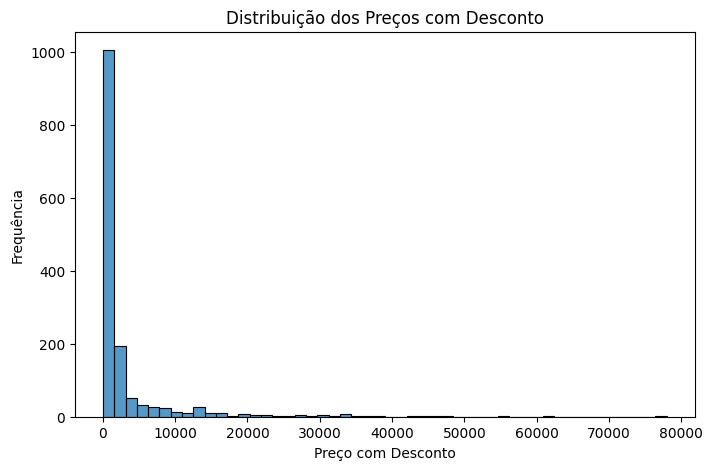

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(df['discounted_price'], bins=50)

plt.title('Distribuição dos Preços com Desconto')
plt.xlabel('Preço com Desconto')
plt.ylabel('Frequência')

plt.show()

O histograma da variável discounted_price apresenta uma distribuição fortemente assimétrica à direita.

Observa-se que a grande maioria dos produtos está concentrada em faixas de preço mais baixas, com alta frequência nos valores próximos ao mínimo.

Por outro lado, há uma longa cauda à direita, indicando a presença de produtos com preços significativamente mais elevados, embora em menor quantidade.

Essa distribuição sugere que o conjunto de dados contém muitos produtos acessíveis e poucos itens de alto valor, caracterizando a presença de outliers.

Esse comportamento confirma o que foi observado nas estatísticas descritivas, onde a média é superior à mediana, evidenciando a influência de valores extremos na distribuição.

A concentração de valores baixos pode indicar que a plataforma possui maior oferta de produtos de baixo custo, enquanto os produtos mais caros representam uma parcela menor do catálogo.

Além disso, a presença de outliers pode impactar análises baseadas na média, sendo recomendável o uso de medidas como a mediana para representar melhor o comportamento típico dos dados.

### *actual_price*

Objetivo: Entender a distribuição dos preços originais dos produtos.

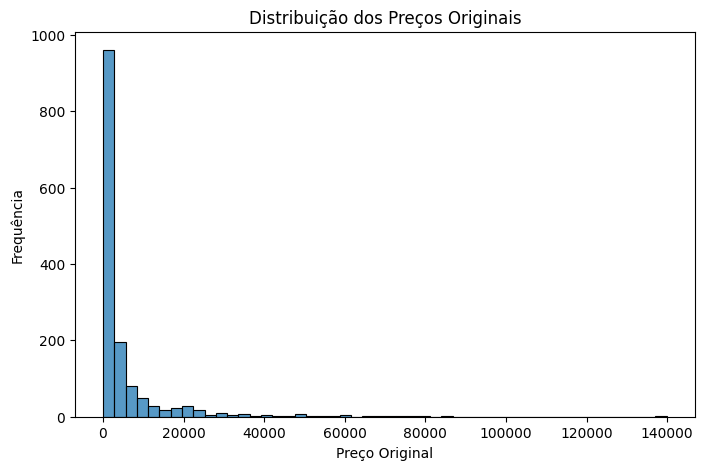

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df['actual_price'], bins=50)

plt.title('Distribuição dos Preços Originais')
plt.xlabel('Preço Original')
plt.ylabel('Frequência')

plt.show()

O histograma da variável actual_price apresenta uma distribuição fortemente assimétrica à direita, semelhante ao observado para os preços com desconto.

A maior parte dos produtos está concentrada em faixas de preço mais baixas, enquanto uma pequena parcela apresenta valores significativamente mais elevados, evidenciando a presença de outliers.

A longa cauda à direita indica que existem produtos com preços muito superiores à maioria, o que impacta diretamente na média dos valores.

Esse comportamento reforça o padrão identificado anteriormente, mostrando que a estrutura de preços dos produtos se mantém tanto antes quanto após a aplicação de descontos.

### *rating*

Objetivo: Compreender a distribuição das avaliações dos produtos e o comportamento geral das notas atribuídas pelos usuários.

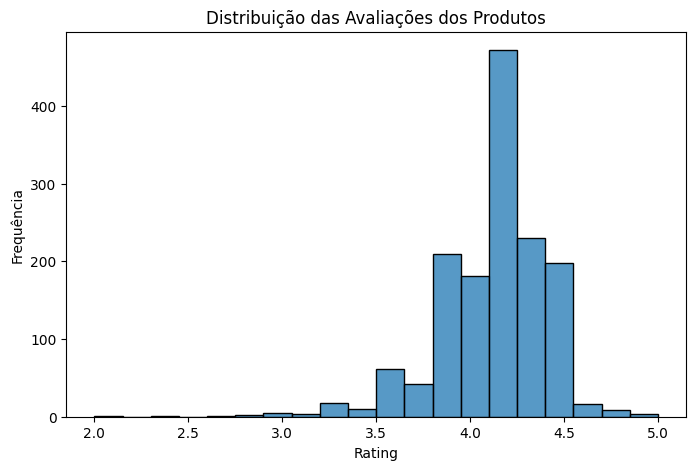

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(df['rating'], bins=20)

plt.title('Distribuição das Avaliações dos Produtos')
plt.xlabel('Rating')
plt.ylabel('Frequência')

plt.show()

O histograma da variável rating apresenta uma distribuição concentrada em valores elevados, com maior frequência entre aproximadamente 3.8 e 4.5.

Observa-se uma baixa dispersão dos dados, indicando que as avaliações dos produtos tendem a ser relativamente homogêneas.

Há uma predominância de avaliações acima de 4.0, sugerindo que a maioria dos produtos possui boa aceitação por parte dos usuários.

Além disso, valores mais baixos de avaliação são pouco frequentes, indicando que produtos mal avaliados representam uma pequena parcela do dataset.

## Boxplot

O objetivo do boxplot é analisar a dispersão dos dados e identificar a presença de outliers, permitindo compreender a variabilidade dos valores e a distribuição geral das variáveis.


**Foi utilizado um único boxplot para análise dos preços, uma vez que esse tipo de visualização já permite identificar a dispersão dos dados e a presença de outliers de forma clara, evitando redundância na apresentação dos resultados.**

### *preços*


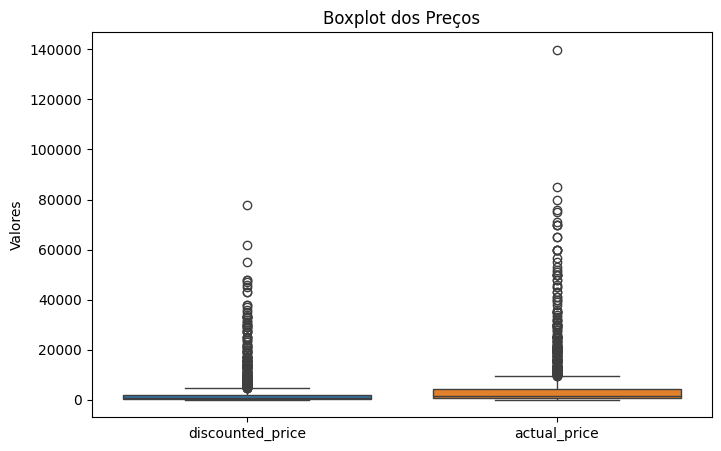

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[['discounted_price', 'actual_price']])

plt.title('Boxplot dos Preços')
plt.ylabel('Valores')

plt.show()

O boxplot das variáveis discounted_price e actual_price evidencia uma alta dispersão nos dados, com a presença de diversos outliers, representados pelos pontos acima do limite superior.

Observa-se que a maior parte dos valores está concentrada em faixas mais baixas, enquanto poucos produtos apresentam preços significativamente elevados.

A mediana encontra-se próxima à base da distribuição, reforçando a concentração de valores mais baixos.

Além disso, a variável actual_price apresenta maior amplitude e quantidade de outliers em comparação com discounted_price, indicando que os preços originais possuem maior variabilidade.

Esse comportamento confirma os padrões identificados anteriormente nos histogramas e nas estatísticas descritivas, evidenciando uma distribuição assimétrica com presença de valores extremos.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

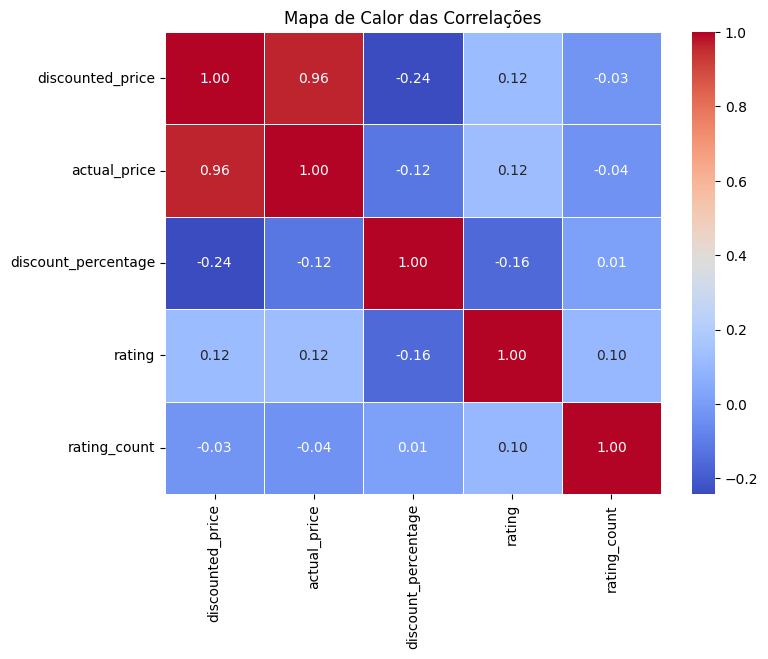

In [44]:
# Matriz de correlação
plt.figure(figsize=(8,6))

corr = df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].corr()

# Mapa de calor
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Mapa de Calor das Correlações')

plt.show()

A análise conjunta da matriz de correlação e do mapa de calor permite identificar de forma clara e visual as relações entre as variáveis numéricas do dataset.

Observa-se uma forte correlação positiva entre actual_price e discounted_price, evidenciada tanto pelos valores numéricos elevados quanto pela intensidade da cor no mapa de calor, indicando que produtos com preços originais mais altos tendem a manter preços elevados mesmo após a aplicação de descontos.

A variável discount_percentage apresenta correlação negativa com os preços, o que é coerente com a lógica de que maiores descontos resultam em preços finais menores. Essa relação também é destacada visualmente pelas tonalidades mais frias no mapa de calor.

As variáveis relacionadas às avaliações (rating e rating_count) apresentam correlações fracas com os preços, o que pode ser observado tanto pelos valores próximos de zero quanto pela coloração mais neutra no mapa de calor, indicando baixa associação linear.

De modo geral, a combinação da matriz numérica com a representação visual facilita a identificação dos padrões de correlação, evidenciando que, com exceção da relação entre os preços, as variáveis apresentam comportamentos relativamente independentes.

## Tratamento de Valores Nulos

O tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [45]:
# Verificar a presença de valores nulos no dataset original
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,1
rating_count,2
about_product,0
user_id,0


In [46]:
# remoção das linhas
df = df.dropna(subset=['rating', 'rating_count'])

Foi realizada a verificação de valores ausentes no dataset, sendo identificados registros faltantes nas variáveis rating e rating_count.

Como a quantidade de valores ausentes era reduzida, optou-se pela remoção dessas observações, evitando possíveis distorções na análise.

# Pré-Processamento de Dados

Nesta etapa, são realizadas operações de pré-processamento com o objetivo de melhorar a qualidade dos dados, garantindo consistência, padronização e adequação para análises futuras.

**Já foram feitos o tratamento de valores nulos e a verificação de tipos.**

In [47]:
# Remoção de colunas irrelevantes
df_model = df.drop(columns=[
    'product_id',
    'product_name',
    'about_product',
    'user_id',
    'user_name',
    'review_id',
    'review_title',
    'review_content',
    'img_link',
    'product_link'
])

Foram removidas colunas textuais e identificadores que não agregam valor direto à análise numérica, com o objetivo de simplificar o dataset e focar nas variáveis mais relevantes.

## Normalização

O objetivo da normalização é ajustar os valores das variáveis para uma mesma escala, geralmente entre 0 e 1, preservando a distribuição dos dados e facilitando a comparação entre diferentes atributos.



In [48]:
# Importando biblioteca MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Colunas numéricas do dataset tratado
cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

# Criar cópia do dataframe sem alterar o original
df_norm = df_model.copy()

# Aplicar normalização
scaler = MinMaxScaler()
df_norm[cols] = scaler.fit_transform(df_norm[cols])

# Visualizar apenas as colunas numéricas normalizadas (amostra)
df_norm[cols].head()

,discounted_price,actual_price,discount_percentage,rating,rating_count
0,0.00,0.01,0.68,0.73,0.06
1,0.00,0.00,0.46,0.67,0.10
2,0.00,0.01,0.96,0.63,0.02
3,0.00,0.00,0.56,0.73,0.22
4,0.00,0.00,0.65,0.73,0.04


In [49]:
# Comparação antes x depois da normalização (amostra)
for col in cols:
    display(
        pd.DataFrame({
            f'{col}_original': df_model[col].head().values,
            f'{col}_normalizado': df_norm[col].head().values
        }).round(3)
    )

,discounted_price_original,discounted_price_normalizado
0,399.00,0.01
1,199.00,0.00
2,199.00,0.00
3,329.00,0.00
4,154.00,0.00


,actual_price_original,actual_price_normalizado
0,"1,099.00",0.01
1,349.00,0.00
2,"1,899.00",0.01
3,699.00,0.01
4,399.00,0.00


,discount_percentage_original,discount_percentage_normalizado
0,64,0.68
1,43,0.46
2,90,0.96
3,53,0.56
4,61,0.65


,rating_original,rating_normalizado
0,4.20,0.73
1,4.00,0.67
2,3.90,0.63
3,4.20,0.73
4,4.20,0.73


,rating_count_original,rating_count_normalizado
0,"24,269.00",0.06
1,"43,994.00",0.10
2,"7,928.00",0.02
3,"94,363.00",0.22
4,"16,905.00",0.04


Após a aplicação da normalização, observa-se que todas as variáveis numéricas passaram a apresentar valores entre 0 e 1, eliminando diferenças de escala entre os atributos.

Esse processo permite que variáveis com ordens de grandeza distintas, como preços e quantidade de avaliações, sejam comparadas de forma mais equilibrada.

A normalização mantém a proporção original dos dados, alterando apenas sua escala, o que contribui para uma análise mais consistente.

## Padronização

A padronização foi aplicada com o objetivo de transformar os dados para que apresentem média igual a 0 e desvio padrão igual a 1, permitindo uma análise mais centrada no comportamento das variáveis em relação à média.

In [50]:
# Importar e inicializar o StandardScaler
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()

# Colunas numéricas do dataset
cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

# Criar cópia do dataframe sem alterar o original
df_std = df_model.copy()

# Aplicar padronização
scaler = StandardScaler()
df_std[cols] = scaler.fit_transform(df_std[cols])

# Visualizar apenas as colunas numéricas padronizadas (amostra)
df_std[cols].head()

,discounted_price,actual_price,discount_percentage,rating,rating_count
0,-0.39,-0.40,0.76,0.36,0.14
1,-0.42,-0.47,-0.22,-0.33,0.60
2,-0.42,-0.33,1.96,-0.68,-0.24
3,-0.40,-0.44,0.25,0.36,1.78
4,-0.43,-0.46,0.62,0.36,-0.03


In [51]:
# Comparação antes x depois da padronização (amostra)
for col in cols:
    display(pd.DataFrame({
        f'{col}_original': df_model[col].head(),
        f'{col}_padronizado': df_std[col].head()
    }).round(3))

,discounted_price_original,discounted_price_padronizado
0,399.00,-0.39
1,199.00,-0.42
2,199.00,-0.42
3,329.00,-0.40
4,154.00,-0.43


,actual_price_original,actual_price_padronizado
0,"1,099.00",-0.40
1,349.00,-0.47
2,"1,899.00",-0.33
3,699.00,-0.44
4,399.00,-0.46


,discount_percentage_original,discount_percentage_padronizado
0,64,0.76
1,43,-0.22
2,90,1.96
3,53,0.25
4,61,0.62


,rating_original,rating_padronizado
0,4.20,0.36
1,4.00,-0.33
2,3.90,-0.68
3,4.20,0.36
4,4.20,0.36


,rating_count_original,rating_count_padronizado
0,"24,269.00",0.14
1,"43,994.00",0.60
2,"7,928.00",-0.24
3,"94,363.00",1.78
4,"16,905.00",-0.03


Observa-se que os valores padronizados passam a representar a distância em relação à média da variável, podendo assumir valores negativos e positivos.

Essa transformação mantém a estrutura dos dados, mas altera sua escala e centralização, permitindo comparações mais adequadas entre diferentes atributos.

## Outras Transformações e Etapas de Pré-Processamento

Além das etapas já realizadas, outras transformações poderiam ser aplicadas para enriquecer a análise e melhorar a qualidade dos dados.

Uma possível abordagem seria a seleção de características, mantendo apenas as variáveis mais relevantes para o problema, o que poderia reduzir a complexidade do dataset e melhorar a eficiência de análises futuras.

Outra possibilidade seria a criação de novas variáveis (feature engineering), como, por exemplo, a diferença entre o preço original e o preço com desconto, permitindo analisar o valor absoluto do desconto aplicado aos produtos.

Também poderia ser aplicada a redução de dimensionalidade, como o uso de técnicas como PCA, especialmente em cenários com maior número de variáveis, com o objetivo de simplificar os dados mantendo a maior parte da informação relevante.

Por fim, poderiam ser exploradas técnicas adicionais de tratamento de dados, como discretização de variáveis ou transformação de distribuições, visando melhorar a qualidade das análises e possíveis modelos futuros.



# Respondendo nossas hipóteses



## Hipótese 1 - Produtos com menor preço tendem a possuir avaliações mais altas.

A análise não evidenciou uma relação significativa entre preço e avaliação dos produtos. A matriz de correlação mostrou uma correlação muito fraca entre preço e rating, indicando que produtos mais baratos não necessariamente possuem avaliações mais altas.

Dessa forma, essa hipótese não foi confirmada.

## Hipótese 2 - Produtos com maior número de avaliações tendem a apresentar ratings mais elevados.

A relação entre rating_count e rating também se mostrou fraca, conforme observado na matriz de correlação. Isso indica que produtos com maior número de avaliações não apresentam, necessariamente, melhores avaliações.

Portanto, essa hipótese não foi confirmada.

## Hipótese 3 - Existem diferenças significativas de preço entre as categorias de produtos.

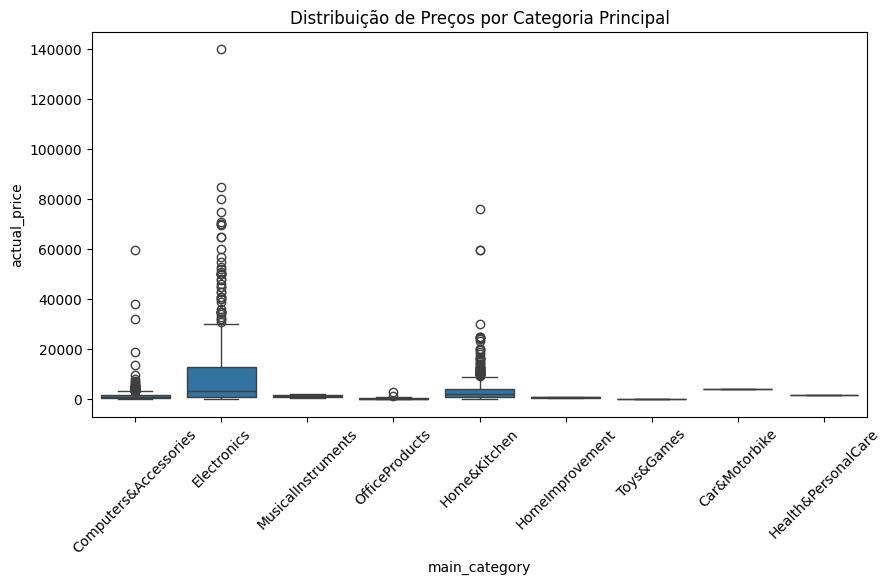

In [52]:
# Agrupamento de categorias principais
df_model['main_category'] = df_model['category'].apply(lambda x: x.split('|')[0])

# Demonstração gráfica
plt.figure(figsize=(10,5))

sns.boxplot(x='main_category', y='actual_price', data=df_model)

plt.xticks(rotation=45)
plt.title('Distribuição de Preços por Categoria Principal')

plt.show()

O boxplot da variável actual_price por categoria principal evidencia diferenças significativas nos preços entre os grupos de produtos.

Observa-se que a categoria Electronics apresenta maior dispersão e os valores mais elevados, incluindo diversos outliers, indicando a presença de produtos com preços significativamente superiores aos demais.

Outras categorias, como Home&Kitchen e Computers&Accessories, também apresentam variação de preços, porém em menor escala.

Já categorias como OfficeProducts, Toys&Games e Health&PersonalCare concentram seus valores em faixas mais baixas, com menor dispersão.

Esses resultados indicam que o tipo de produto exerce influência direta sobre a precificação, confirmando a hipótese de que existem diferenças significativas de preço entre as categorias.

Dessa forma, a hipótese foi confirmada, uma vez que diferentes categorias apresentam padrões distintos de distribuição de preços.

## Hipótese 4 - Produtos com maiores descontos tendem a possuir melhores avaliações.

A correlação entre discount_percentage e rating foi fraca e ligeiramente negativa, indicando que maiores descontos não estão associados a melhores avaliações.

Assim, essa hipótese não foi confirmada.

## Hipótese 5 - Algumas categorias concentram a maior parte dos produtos disponíveis.

A análise da variável category indicou a presença de categorias com maior frequência de produtos, sugerindo uma concentração em determinados segmentos.

Dessa forma, essa hipótese foi confirmada.

# Conclusão

A análise exploratória e o pré-processamento do dataset de produtos da Amazon demonstraram a importância de compreender a estrutura e a qualidade dos dados antes de qualquer etapa mais avançada. O dataset apresentou variáveis numéricas e categóricas relevantes, permitindo uma análise abrangente sobre preços, descontos e avaliações dos produtos.

A análise exploratória revelou padrões importantes, como a forte assimetria na distribuição dos preços e a presença de outliers, além da baixa correlação entre preço e avaliação dos produtos. As visualizações, especialmente histogramas, boxplots e a matriz de correlação, foram fundamentais para identificar esses comportamentos e compreender melhor a relação entre as variáveis.

As etapas de pré-processamento, incluindo tratamento de valores nulos, remoção de colunas irrelevantes, normalização e padronização, contribuíram para a melhoria da qualidade dos dados e preparação para possíveis análises futuras.

As hipóteses levantadas foram analisadas com base nos dados:

1. **Produtos com menor preço tendem a possuir avaliações mais altas?**

Não foi identificada relação significativa entre preço e avaliação, indicando que produtos mais baratos não necessariamente possuem melhores ratings.


2. **Produtos com maior número de avaliações tendem a apresentar ratings mais elevados?**

A análise mostrou correlação fraca entre quantidade de avaliações e rating, não confirmando a hipótese.


3. **Existem diferenças significativas de preço entre as categorias de produtos?**

Sim, a análise por categoria evidenciou variações relevantes de preço entre os diferentes grupos, confirmando a hipótese.


4. **Produtos com maiores descontos tendem a possuir melhores avaliações?**

Não foi observada relação significativa entre desconto e avaliação, não confirmando a hipótese.


5. **Algumas categorias concentram a maior parte dos produtos disponíveis?**

Sim, foi possível identificar maior concentração de produtos em determinadas categorias, confirmando a hipótese.

--

De forma geral, os resultados indicam que fatores como preço e desconto não possuem forte influência direta nas avaliações dos produtos, enquanto o tipo de produto (categoria) exerce papel relevante na definição de preços.

O trabalho evidencia a importância da análise exploratória como etapa fundamental no entendimento dos dados, permitindo identificar padrões, validar hipóteses e orientar decisões em etapas futuras, como modelagem ou tomada de decisão.